# ДЗ Линейная регрессия

В данном задании мы рассмотрим набор данных об учащихся, собранный в 2006 году в одной из школ Португалии. Данные представлены в неудобном для машинного обучения виде, и содержат мусор. Ваша задача &mdash; привести их к надлежащему виду и обучить на них простую модель.

Данные состоят из четырех файлов:
- data.csv &mdash; основная таблица с информацией о учащихся
- scores.csv &mdash; список финальных оценок по одному из предметов (20-балльная шкала переведенная в проценты)
- attendance.csv &mdash; таблица посещений занятий по этому предмету
- school_support.txt &mdash; список учащихся, которым оказывается финансовая поддержка

Ваша задача &mdash; построить модель для предсказания финальных оценок исходя из всех остальных данных и проверить качество ее работы с помощью кросс-валидации. В качестве алгоритма мы будем использовать линейную регрессию

Расшифровка столбцов в data.csv для справки:
- age &mdash; возраст
- Medu &mdash; уровень образования матери (по некоторой условной шкале)
- Fedu &mdash; уровень образования отца (по некоторой условной шкале)
- traveltime &mdash; время в пути до школы (1 – < 15 мин., 2 – от 15 до 30 мин., 3 – от 30 мин. to 1 ч.
или 4 – > 1 ч.)
- studytime &mdash; время, затрачиваемое на занятия вне школы (1 – < 2 ч., 2 – от 2 до 5 ч., 3 – от 5 до 10 ч. или 4 – > 10 ч.)
- famrel &mdash; насколько хорошие отношения в семье у учащегося (по некоторой условной шкале)
- freetime &mdash; количество свободного времени вне школы (по некоторой условной шкале)
- goout &mdash; время, затрачиваемое на общение с друзьями (по некоторой условной шкале)
- Dalc &mdash; количество употребления алкоголя в учебные дни (по некоторой условной шкале)
- Walc &mdash; количество употребления алкоголя в неучебные дни (по некоторой условной шкале)
- health &mdash; уровень здоровья (по некоторой условной шкале)
- sex_M &mdash; пол: мужской (1) или женский (0)
- address_U &mdash; живет ли учащийся в городе (1) или в пригороде (0)
- famsize_LE3 &mdash; размер семьи: не больше 3 человек (1) или больше (0)
- Pstatus_T &mdash; живут ли родители вместе (1) или отдельно (0)
- nursery &mdash; посещал ли учащийся детский сад
- plans_university &mdash; планирует ли учащийся поступать в университет (-1 или 1)
- past_failures &mdash; количество неудовлетворительных оценок по другим предметам ранее (от 0 до 4)

*Примечание. Несколько признаков в данных содержат ошибки/проблемы/некорректности. Эти проблемы нужно исправить. Для
проверки &mdash; всего в данных таких проблем четыре.*

Начиная с 4 пункта делайте кроссвалидацию на 4 батча до и после, замеряйте результат

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Задача 1: сломанный признак (а может и не один)
__(1 балл)__

Загрузите таблицу data.csv.

Найдите в данных сломанный признак (он не соответствует описанию) и исправьте его.

In [86]:
data = pd.read_csv('data.csv')
a = data['plans_universitypast_failures']
data['plans_university'] = a.astype(str).str[:-1].astype(int)
data['past_failures'] = a.astype(str).str[-1].astype(int)
del data['plans_universitypast_failures']
data.loc[data['age'] > 40, 'age'] = 2006 - data.loc[data['age'] > 40, 'age']
data.loc[(data['traveltime'] >= 5) & (data['traveltime'] < 15), 'traveltime'] = 1
data.loc[(data['traveltime'] >= 15) & (data['traveltime'] < 30), 'traveltime'] = 2
data.loc[(data['traveltime'] >= 30) & (data['traveltime'] < 60), 'traveltime'] = 3
data.loc[(data['traveltime'] >= 60), 'traveltime'] = 4
data
scores = pd.read_csv('scores.csv', header=None, names=['score'])
mask_small = (scores['score'] > 0) & (scores['score'] < 1)
scores.loc[mask_small, 'score'] = 100 * scores.loc[mask_small, 'score']
scores.loc[scores['score'] == 5, 'score'] = 50

### Задача 2: пропуски в данных 
__(1 балл)__

Проверьте, есть ли в данных пропуски (значения NaN). Замените все пропущенные значения на среднее значение этого признака по столбцу.

*Hint: изучите в pandas функции loc, isnull, а также передачу булевых массивов в качестве индексов.*

In [87]:
data = data.fillna(data.mean())

### Задача 3: нормализация данных
__(1 балл)__

Нормализуйте данные любым способом, в современных библиотеках нормализация часто встроена внутрь модели, поэтому тут разницы может и не быть в качестве, но сделать надо

In [63]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X = scaler.fit_transform(data)
X = pd.DataFrame(X, columns=data.columns)


### Задача 4: кросс-валидация для исходных данных
__(1 балл)__

Загрузите файл scores.csv и протестируйте, как линейная регрессия предсказывает ответ сейчас (с помощью кросс-валидации).

Кроссвалидацию сделайте по 4 разбивкам. Выведите качество в каждом их разбиений.

*Hint: воспользуйтесь sklearn.linear_model и sklearn.model_selection.*

In [72]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import make_pipeline
Y = scores
kf = KFold(n_splits=4, shuffle=True, random_state=67)
model = make_pipeline(MinMaxScaler(), LinearRegression())
r2_scores = cross_val_score(model, X, y, cv=kf, scoring='r2')
mse_scores = -cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error')
for i, (r2, mse) in enumerate(zip(r2_scores, mse_scores)):
    print(i, r2, mse)

0 0.22182282875700388 262.9911407774215
1 0.05537761558472043 254.2362026901408
2 0.38716014995031134 152.14979907726533
3 0.20346367798736986 224.3335809505915


### Задача 5: полные данные
__(2 балла)__

Воспользуйтесь файлами attendance.csv и school_support.txt для того, чтобы добавить новые признаки в данные. Желательно по максимуму использовать возможности pandas для упрощения преобразований.

school_suport число в строке значит что i-ый школьник из исходной таблицы получал мат помощь (обратите внимание что строк в файле меньше, подумайте как правильно импортировать данные)

Добавьте данные таким образом, чтобы качество выросло

In [65]:
att = pd.read_csv('attendance.csv', sep=';')
att_plus = att.eq('+').sum(axis=1)
att2 = pd.DataFrame({
    'attendance_plus': att_plus,
    'attendance_rate': att_plus / att.shape[1]
})
with open('school_support.txt', 'r') as f:
    supp_ids = [int(t) - 1 for t in f.read().split()]
X['school_support'] = 0
X.loc[supp_ids, 'school_support'] = 1
X = pd.concat([X, att2], axis=1)
X

,age,Medu,Fedu,traveltime,studytime,famrel,freetime,goout,Dalc,Walc,...,sex_M,address_U,famsize_LE3,Pstatus_T,nursery,plans_university,past_failures,school_support,attendance_plus,attendance_rate
0,0.142857,1.00,1.00,0.000000,0.333333,1.00,0.75,0.75,0.00,0.25,...,1.0,1.0,0.0,1.0,1.0,1.0,0.000000,0,26,0.81250
1,0.285714,1.00,1.00,0.000000,0.000000,1.00,0.50,0.75,0.00,0.25,...,0.0,1.0,0.0,1.0,1.0,1.0,0.000000,0,30,0.93750
2,0.142857,0.25,0.25,0.333333,0.000000,0.75,1.00,1.00,0.25,0.75,...,1.0,0.0,1.0,1.0,1.0,1.0,0.000000,0,32,1.00000
3,0.428571,0.25,0.50,0.333333,0.000000,0.50,0.75,0.75,0.25,0.75,...,1.0,1.0,0.0,1.0,0.0,0.0,0.000000,0,22,0.68750
4,0.285714,0.50,0.25,0.333333,0.333333,0.75,0.25,1.00,0.00,0.25,...,0.0,0.0,0.0,1.0,1.0,1.0,0.000000,0,32,1.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,0.428571,0.50,0.50,1.000000,0.333333,0.75,0.25,1.00,0.00,0.00,...,0.0,1.0,0.0,1.0,1.0,1.0,0.000000,0,30,0.93750
645,0.000000,1.00,1.00,0.333333,0.333333,0.75,0.50,0.00,0.00,0.00,...,1.0,1.0,0.0,1.0,1.0,1.0,0.000000,0,30,0.93750
646,0.857143,0.25,0.25,0.333333,0.333333,1.00,0.50,0.50,1.00,0.25,...,1.0,0.0,1.0,1.0,1.0,0.0,0.666667,0,11,0.34375
647,0.142857,0.50,0.50,0.000000,0.000000,0.75,0.50,0.75,0.00,0.25,...,0.0,1.0,1.0,0.0,1.0,0.0,0.000000,0,26,0.81250


### Задача 6: борьба с выбросами
__(1.5 балла)__

Качество предсказания может ухудшаться, если в данных присутствуют корректные значения признаков (с точки зрения чтения данных и применения методов), но не соответствующие реальным объектам. Например, данные могли быть введены в неверном формате, а потом слишком грубо приведены к общему виду, из-за чего ошибка не была замечена.
Попробуем от такого избавиться &mdash; а для этого такие объекты нужно сначала найти. Конечно, нам еще недоступны многие продвинутые способы, но давайте попробуем обойтись простыми.

Первый способ это сделать &mdash; посмотреть для каждого признака на распределение его значений и проверить крайние значения на правдоподобность. (постройте гистограммы для признаков, как минимум для подозрительных)

*Hint 1: используйте функцию DataFrame.hist*

*Hint 2: в описании датасета выше есть информация, необходимая для восстановления правильных значений*

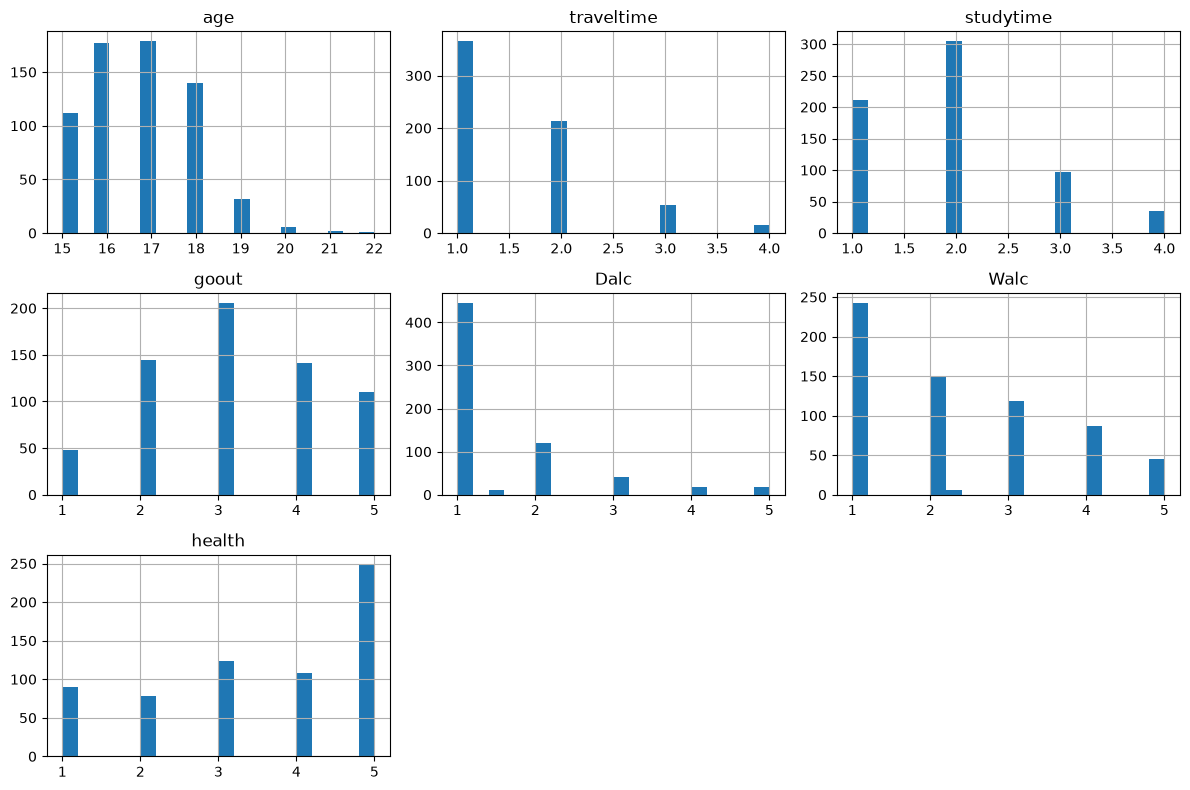

In [88]:
data[['age', 'traveltime', 'studytime', 'goout', 'Dalc', 'Walc', 'health']].hist(
    figsize=(12, 8), bins=20
)
plt.tight_layout()
plt.show()

__(1.5 балла)__

Другой простой способ найти выбросы &mdash; сделать предсказание и посчитать ошибку на каждом объекте по отдельности и посмотреть на объекты с наибольшей ошибкой. Обучите линейную регрессию (функция fit) и для каждого объекта посчитайте среднеквадратичное отклонение. Постройте гистограмму распределения ошибок. Посмотрите на гистограмму и удалите из выборки те объекты на которых ошибка слишком большая.

Обратите внимание, что просто удалять все объекты с высокой ошибкой нельзя &mdash; это, конечно, хороший способ добиться меньшей ошибки (на данной выборке), но одновременно вы ухудшите обобщающую способность алгоритма. Вместо этого вам нужно найти однозначно ошибочные записи и их исправить.

*Hint: возможно, все проблемы уже были найдены первым способом; для проверки &mdash; в сумме здесь нужно исправить 3 проблемы.*

Для поиска ошибки на одном отдельном обьекте придётся обучить линейную регрессию руками. Частичный пример, допишите код. Постройте гистограмму распределения ошибок

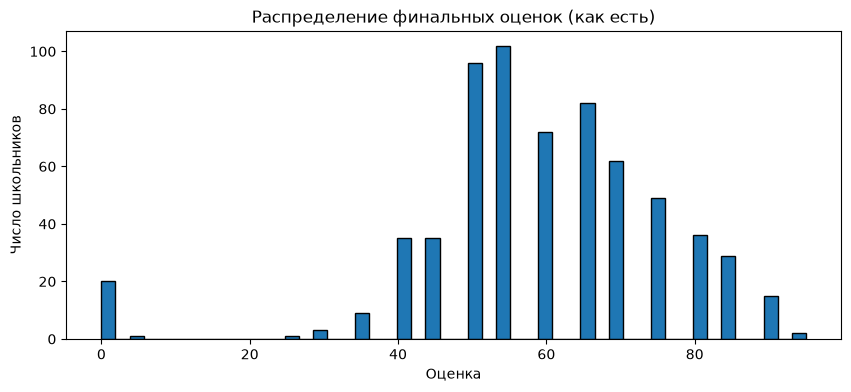

In [90]:
plt.figure(figsize=(10, 4))
plt.hist(y, bins=50, edgecolor='black')
plt.title('Распределение финальных оценок (как есть)')
plt.xlabel('Оценка')
plt.ylabel('Число школьников')
plt.show()

In [7]:
import sklearn
from sklearn import linear_model
regression = linear_model.LinearRegression().fit(data, result) #create model and train it
prediction = #calculate prediction for one object for vector x
error = (prediction - y)**2 #simple error - square error

SyntaxError: invalid syntax (3289234131.py, line 4)

In [ ]:
# Your code here
# ...

### Финальное предсказание и отчёт (1 балл)

Проведите предсказание еще раз и сравните качество с исходным. Запишите свои наблюдения - как изменялось качество обучения модели при использовании разных модификаций данных. 

In [ ]:
# Your code here
# ...